## How does the spectral resolution R = $\lambda / \Delta \lambda$ vary for each grating/filter?

### Some NIRSpec Docs
- [Dispersers & Filters](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-dispersers-and-filters#gsc.tab=0)

In [1]:
import os
os.environ["pandeia_refdata"] = "../../data/pandeia_data-2026.7-jwst"

import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

refdata = os.environ["pandeia_refdata"]

# Fixed-slit aperture (the coverage/detector gap depends on this)
aperture = 's200a1'

# grating/filter combinations to display
combos = [('prism', 'clear'),
          ('g140m', 'f070lp'), ('g140m', 'f100lp'),
          ('g140h', 'f070lp'), ('g140h', 'f100lp'),
          ('g235m', 'f170lp'), ('g235h', 'f170lp'),
          ('g395m', 'f290lp'), ('g395h', 'f290lp')]

# per-grating dispersion files (WAVELENGTH, DLDS, R)
disp_files = {os.path.basename(f).split('_')[2]: f
              for f in glob.glob(f"{refdata}/jwst/nirspec/dispersion/*_disp_*.fits")}

# NIRSpec fixed-slit wavelength coverage, read from Pandeia's slit_config.
_gap = json.load(open(f"{refdata}/jwst/nirspec/config.json"))['slit_config'][aperture]['gap']['default']


def coverage(disp, filt):
    """Wavelength coverage (wmin, wmax) in microns for a grating/filter combo."""
    node = _gap[disp]
    v = node if 'wave_min' in node else node[filt]   # some gratings nest by filter
    return v['wave_min'], v['wave_max']


# Emission line + velocity window to mark on the figure and evaluate R against
line_rest_um = 0.6563 # H alpha rest wavelength (um)
redshift = 6.5
vwin_kms = 1_000.0 # +/- velocity half-window around the line centre
c_kms = 299792.458

obs = line_rest_um * (1 + redshift) # observed line centre (um)
w_lo = obs * (1 - vwin_kms / c_kms) # window edges from +/- v
w_hi = obs * (1 + vwin_kms / c_kms)

grating/filter   coverage (um)    R range       
----------------------------------------------
prism/clear      0.60-5.30        30-323        
g140m/f070lp     0.70-1.27        499-906       
g140m/f100lp     0.97-1.84        692-1318      
g140h/f070lp     0.81-1.27        1533-2435     
g140h/f100lp     0.97-1.82        1839-3624     
g235m/f170lp     1.66-3.07        705-1312      
g235h/f170lp     1.66-3.05        1875-3623     
g395m/f290lp     2.87-5.09        725-1294      
g395h/f290lp     2.87-5.14        1931-3636     


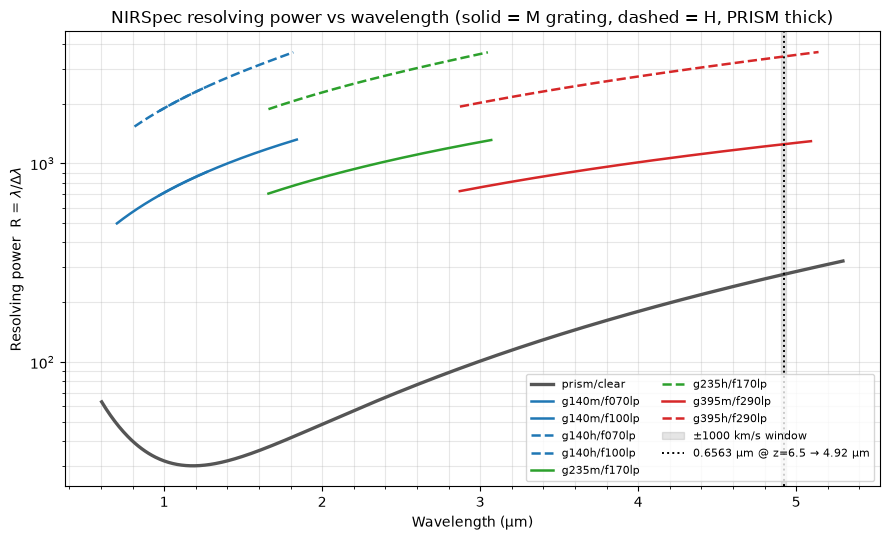

In [2]:
# Colour by wavelength band, line style by resolution class
band_color = {'g140': '#1f77b4', 'g235': '#2ca02c', 'g395': '#d62728', 'pris': '#555555'}
def style(disp):
    if disp == 'prism':
        return band_color['pris'], '-', 2.4
    cls = disp[-1]                       # 'm' or 'h'
    return band_color[disp[:4]], ('-' if cls == 'm' else '--'), 1.8

fig, ax = plt.subplots(figsize=(9, 5.5))
print(f"{'grating/filter':16} {'coverage (um)':16} {'R range':14}")
print('-' * 46)
for disp, filt in combos:
    wmin, wmax = coverage(disp, filt)
    d = fits.getdata(disp_files[disp])
    w, R = d['WAVELENGTH'], d['R']
    m = (w >= wmin) & (w <= wmax)
    color, ls, lw = style(disp)
    ax.plot(w[m], R[m], color=color, ls=ls, lw=lw, label=f"{disp}/{filt}")
    print(f"{disp+'/'+filt:16} {f'{wmin:.2f}-{wmax:.2f}':16} {f'{R[m].min():.0f}-{R[m].max():.0f}':14}")

# Mark the observed line centre and the +/- velocity window
ax.axvspan(w_lo, w_hi, color='k', alpha=0.10, zorder=0,
           label=f'±{vwin_kms:.0f} km/s window')
ax.axvline(obs, color='k', ls=':', lw=1.4,
           label=f'{line_rest_um} µm @ z={redshift} → {obs:.2f} µm')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel(r'Resolving power  R = $\lambda/\Delta\lambda$')
ax.set_title('NIRSpec resolving power vs wavelength (solid = M grating, dashed = H, PRISM thick)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc='lower right')
fig.tight_layout()
plt.minorticks_on()
plt.show()

## Resolving power at a specific line

In [4]:
# --- R at the redshifted line, plus the R range across the +/- velocity window ---
# (line_rest_um, redshift, vwin_kms, obs, w_lo, w_hi are defined in the setup cell)

def line_R(disp, filt):
    """R at the observed line centre and (min, max) R across +/-vwin_kms.
    Returns None if the line is outside this grating/filter's coverage."""
    wmin, wmax = coverage(disp, filt)
    if not (wmin <= obs <= wmax):
        return None
    d = fits.getdata(disp_files[disp])
    w, R = d['WAVELENGTH'], d['R']
    order = np.argsort(w)                     # interp needs ascending x
    w, R = w[order], R[order]
    R_centre = float(np.interp(obs, w, R))
    lo, hi = max(w_lo, wmin), min(w_hi, wmax)  # clip window to coverage
    Rs = np.interp(np.linspace(lo, hi, 101), w, R)
    return R_centre, float(Rs.min()), float(Rs.max())


print(f"Line rest {line_rest_um} um at z={redshift}  ->  observed {obs:.4f} um")
print(f"Velocity window +/-{vwin_kms:.0f} km/s  ->  {w_lo:.4f}-{w_hi:.4f} um\n")
print(f"{'grating/filter':16} {'R @ line':>10} {'R min':>8} {'R max':>8}")
print('-' * 46)
for disp, filt in combos:
    res = line_R(disp, filt)
    if res is None:
        print(f"{disp+'/'+filt:16} {'-- line not covered --':>30}")
        continue
    Rc, Rmin, Rmax = res
    print(f"{disp+'/'+filt:16} {Rc:>10.0f} {Rmin:>8.0f} {Rmax:>8.0f}")

Line rest 0.6563 um at z=6.5  ->  observed 4.9223 um
Velocity window +/-1000 km/s  ->  4.9058-4.9387 um

grating/filter     R @ line    R min    R max
----------------------------------------------
prism/clear             277      275      278
g140m/f070lp             -- line not covered --
g140m/f100lp             -- line not covered --
g140h/f070lp             -- line not covered --
g140h/f100lp             -- line not covered --
g235m/f170lp             -- line not covered --
g235h/f170lp             -- line not covered --
g395m/f290lp           1250     1245     1254
g395h/f290lp           3453     3439     3466
